In [1]:
import h2o
from h2o.automl import H2OAutoML

# Подключаемся к контейнеру H2O (имя сервиса из docker-compose)
h2o.init(url="http://h2o-server:54321")

Checking whether there is an H2O instance running at http://h2o-server:54321. connected.


H2O_cluster_uptime:,5 mins 29 secs
H2O_cluster_timezone:,UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,17 days
H2O_cluster_name:,?
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.859 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [4]:
# H2O использует мультипоточную загрузку, что очень быстро для файлов >100 МБ
df = h2o.import_file("/data/telecom_churn.csv")
print(f"Размерность данных: {df.shape}")
df.head()

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Размерность данных: (1500000, 7)


CustomerID,TenureMonths,MonthlyCharges,TotalCharges,TechSupportCalls,ContractType,Churn
1,52,44.2792,2164.58,3,Month-to-month,No
2,15,105.888,1591.87,2,Month-to-month,No
3,61,43.4037,2429.14,0,One year,No
4,21,85.3758,1664.61,0,One year,No
5,24,76.6727,1855.86,1,Month-to-month,No
6,3,83.5753,267.719,0,Month-to-month,Yes
7,22,59.404,1397.41,1,Month-to-month,No
8,53,66.9538,3663.55,2,Two year,No
9,2,73.9064,144.474,2,One year,No
10,30,69.6627,2006.55,3,Month-to-month,No


In [5]:
target = "Churn"
features = df.columns
features.remove(target)
features.remove("CustomerID") 

df[target] = df[target].asfactor()
train, test = df.split_frame(ratios=[0.8], seed=42)

In [6]:
aml = H2OAutoML(max_models=10, max_runtime_secs=300, seed=42, project_name="Telecom_Churn")
aml.train(x=features, y=target, training_frame=train)

lb = aml.leaderboard
print(lb.head(rows=lb.nrows))

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
model_id                                auc    logloss     aucpr    mean_per_class_error      rmse        mse
XGBoost_3_AutoML_1_20260330_75200  0.967239   0.123767  0.839801                0.140717  0.195579  0.038251
GBM_3_AutoML_1_20260330_75200      0.967169   0.124047  0.839185                0.140846  0.195883  0.0383702
GBM_2_AutoML_1_20260330_75200      0.967089   0.123739  0.839297                0.140938  0.195664  0.0382845
XGBoost_2_AutoML_1_20260330_75200  0.967075   0.124669  0.83866                 0.142108  0.196674  0.0386807
XGBoost_1_AutoML_1_20260330_75200  0.966799   0.126783  0.83759                 0.14382   0.19846   0.0393865
GBM_4_AutoML_1_20260330_75200      0.96678    0.124629  0.838346                0.140794  0.196397  0.0385716
GBM_1_AutoML_1_20260330_75200      0.966748   0.125787  0.838054                0.140717  0.197285  0.0389215
DRF_1_AutoML_1_20260330_75

ModelMetricsBinomial: xgboost
** Reported on test data. **

MSE: 0.038134477194888446
RMSE: 0.1952805089989486
LogLoss: 0.12331702806292269
Mean Per-Class Error: 0.14060163852074145
AUC: 0.9672440453677054
AUCPR: 0.8370870894908462
Gini: 0.9344880907354107

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.35520198941230774
       No      Yes    Error    Rate
-----  ------  -----  -------  ------------------
No     258586  7900   0.0296   (7900.0/266486.0)
Yes    8395    24977  0.2516   (8395.0/33372.0)
Total  266981  32877  0.0543   (16295.0/299858.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.355202     0.754034  215
max f2                       0.134576     0.763071  311
max f0point5                 0.624973     0.82344   112
max accuracy                 0.493111     0.945898  163
max precision                0.99

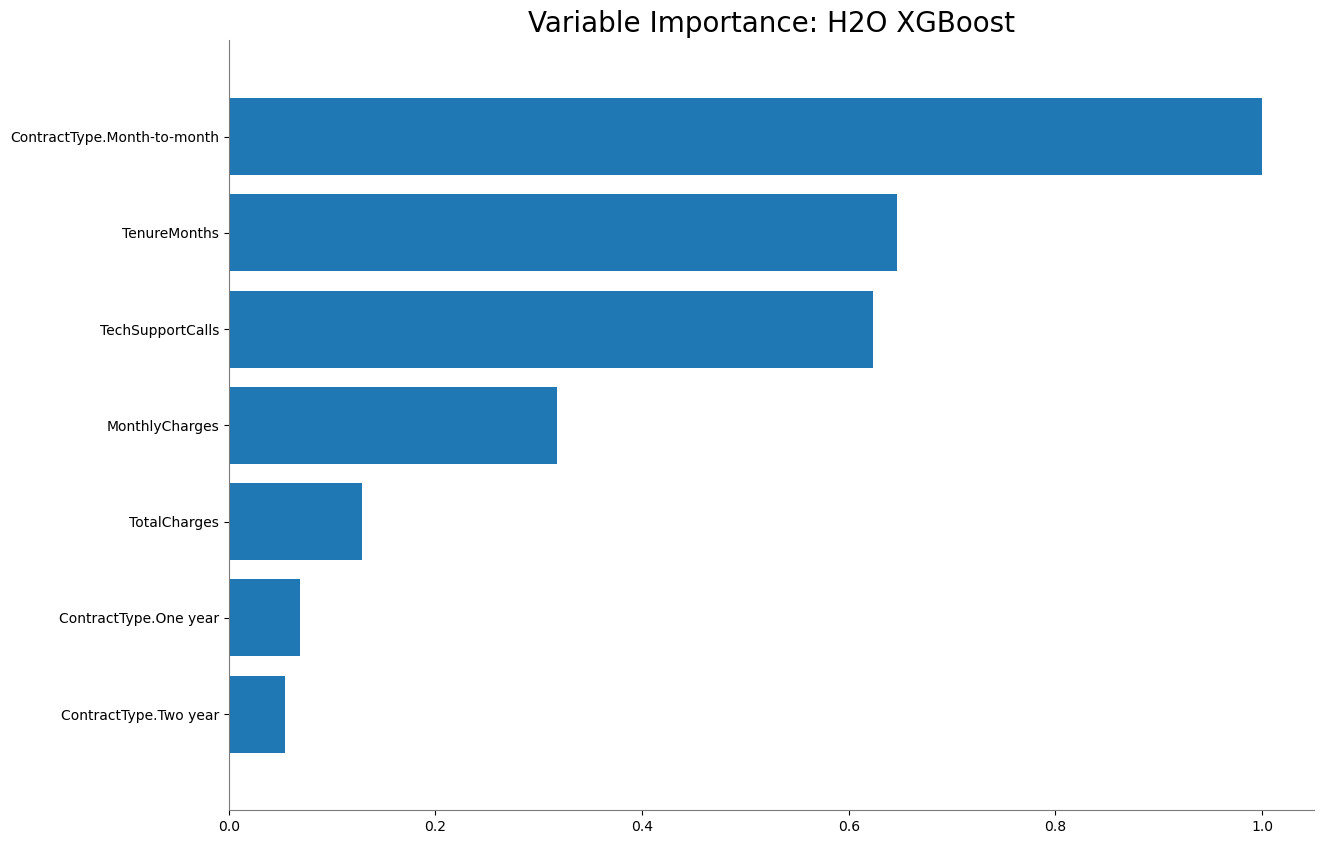

<Figure size 640x480 with 0 Axes>

In [7]:
best_model = aml.leader
perf = best_model.model_performance(test)
print(perf)
best_model.varimp_plot()

In [9]:
# Делаем предсказания
predictions = best_model.predict(test)

# "Yes" 
results = test["CustomerID"].cbind(predictions["Yes"])
results.set_names(["CustomerID", "Churn_Probability"])

# Отбираем топ клиентов с наивысшей вероятностью оттока (>80%)
high_risk_customers = results[results["Churn_Probability"] > 0.80]
print("Клиенты в зоне высокого риска (кандидаты на промо-акции):")
print(high_risk_customers.head(10))

xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%
Клиенты в зоне высокого риска (кандидаты на промо-акции):
  CustomerID    Churn_Probability
          33             0.96121
          55             0.977131
          79             0.976258
         141             0.974919
         174             0.991829
         212             0.992596
         272             0.819629
         470             0.975593
         518             0.845032
         578             0.988522
[10 rows x 2 columns]



In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

sns.set_theme(style="whitegrid")

y_true = test["Churn"].as_data_frame()["Churn"]
y_pred = predictions["predict"].as_data_frame()["predict"]
y_prob = predictions["Yes"].as_data_frame()["Yes"] 

/opt/conda/lib/python3.11/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/opt/conda/lib/python3.11/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/opt/conda/lib/python3.11/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow a

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import warnings

# Отключаем вывод системных предупреждений для чистоты ноутбука
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# Конвертируем данные из H2O Frame в Pandas DataFrame с включенной мультипоточностью
y_true = test["Churn"].as_data_frame(use_multi_thread=True)["Churn"]
y_pred = predictions["predict"].as_data_frame(use_multi_thread=True)["predict"]
y_prob = predictions["Yes"].as_data_frame(use_multi_thread=True)["Yes"] 

print("Данные успешно сконвертированы в Pandas!")

Данные успешно сконвертированы в Pandas!


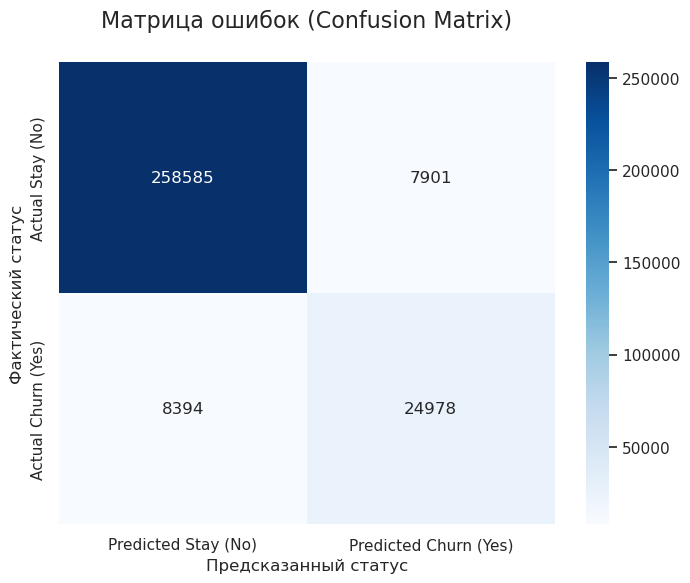

In [12]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred, labels=['No', 'Yes'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Stay (No)', 'Predicted Churn (Yes)'],
            yticklabels=['Actual Stay (No)', 'Actual Churn (Yes)'])

plt.title('Матрица ошибок (Confusion Matrix)\n', fontsize=16)
plt.ylabel('Фактический статус', fontsize=12)
plt.xlabel('Предсказанный статус', fontsize=12)
plt.show()

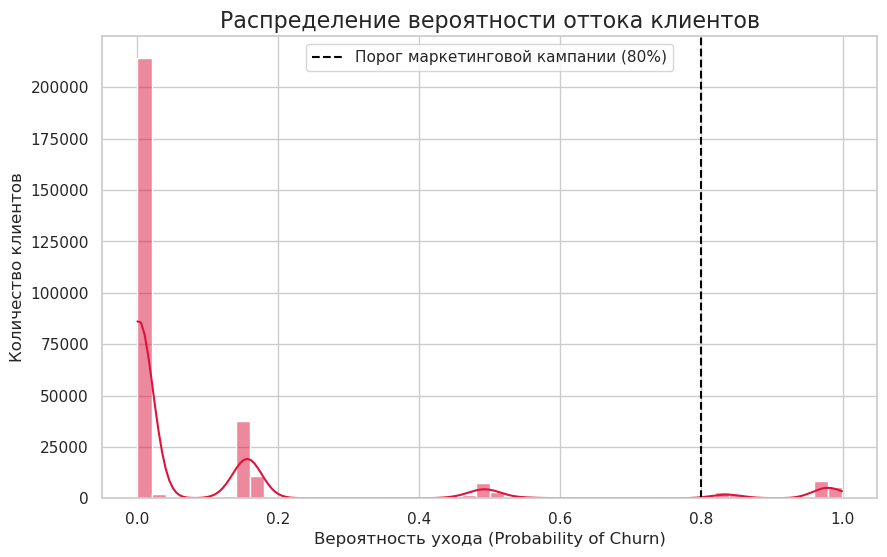

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(y_prob, bins=50, kde=True, color='crimson')

plt.axvline(x=0.8, color='black', linestyle='--', label='Порог маркетинговой кампании (80%)')

plt.title('Распределение вероятности оттока клиентов', fontsize=16)
plt.xlabel('Вероятность ухода (Probability of Churn)', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.legend()
plt.show()

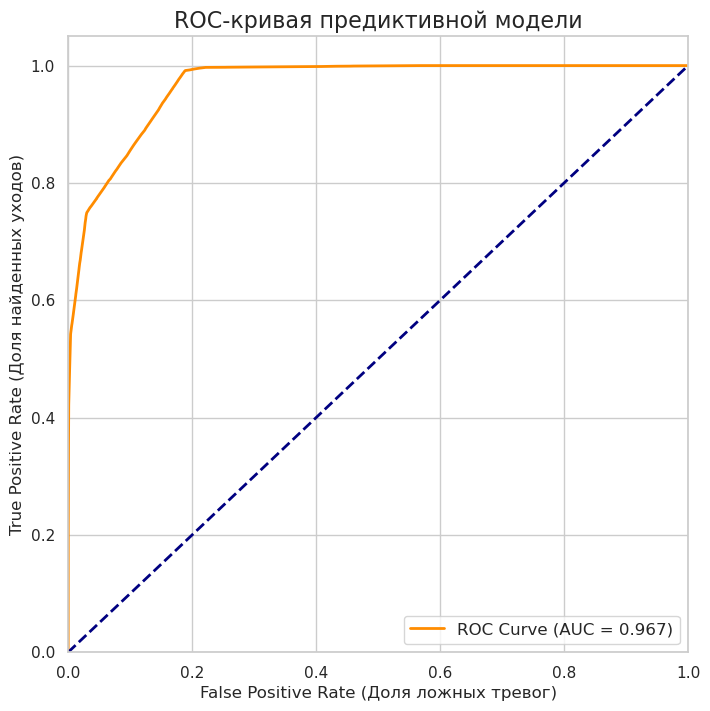

In [14]:
y_true_binary = y_true.map({'Yes': 1, 'No': 0})

fpr, tpr, thresholds = roc_curve(y_true_binary, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Доля ложных тревог)', fontsize=12)
plt.ylabel('True Positive Rate (Доля найденных уходов)', fontsize=12)
plt.title('ROC-кривая предиктивной модели', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.show()